## Módulo 5. Análisis de Calidad del Aire con técnicas de interpolación espacial

In [23]:
import numpy as np
import pandas as pd
import geopandas as gpd

In [24]:
gdf = gpd.read_file('st_rb_2019_nox.gpkg')
gdf['NOx_avg19'].isna().any()
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [25]:
gdf = gdf.dropna(subset=['NOx_avg19'])
gdf['NOx_avg19'].isna().any()
gdf = gdf.to_crs(epsg=3035)
print(gdf.crs)

EPSG:3035


In [26]:
x = gdf.geometry.x.to_numpy()
y = gdf.geometry.y.to_numpy()
coords = np.column_stack([x, y])
values = gdf['NOx_avg19'].to_numpy(dtype=np.float32)

In [27]:
# Creacion de rejilla con Verde 
import verde as vd
region = vd.get_region((x, y))
region = vd.pad_region(region, 50_000)
print(region)

east, north = vd.grid_coordinates(
    region=region,
    spacing=20_000
)

query_coords = np.column_stack([east.ravel(), north.ravel()])

(2628582.163631156, 6586476.244014449, 1405453.6038719688, 5093624.614238417)


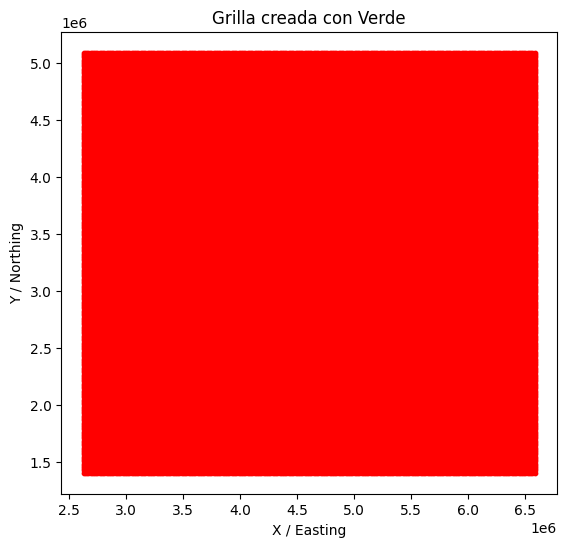

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(east, north, s=10, color='red')
plt.gca().set_aspect("equal")
plt.xlabel("X / Easting")
plt.ylabel("Y / Northing")
plt.title("Grilla creada con Verde")
plt.show()

In [29]:
from scipy.spatial import cKDTree

def idw_interpolation(coords, values, query_coords, radius, power=2, output_shape=None):  
    tree = cKDTree(coords)
    distances, indices = tree.query(query_coords, k=12, distance_upper_bound=radius)
    valid_neighbors_count = np.count_nonzero(np.isfinite(distances), axis=1)
    # if np.any(valid_neighbors_count == 0):
        # raise ValueError("Algunos puntos de consulta no tienen vecinos válidos.")
    mask_min = valid_neighbors_count >= 3
    weights = 1 / np.maximum(distances, 1e-12)**power # Evitar división por cero
    weights[~np.isfinite(distances)] = 0 # Asignar peso cero a vecinos no válidos

    safe_indices = np.where(indices < len(values), indices, 0) 
    neighbor_values = values[safe_indices]

    numerator = np.sum(weights * neighbor_values, axis=1)
    denominator = np.sum(weights, axis=1)

    result = np.full(query_coords.shape[0], np.nan)
    result[mask_min] = numerator[mask_min] / denominator[mask_min]

    return result.reshape(output_shape)

idw_surface = idw_interpolation(
    coords=coords, 
    values=values, 
    query_coords=query_coords, 
    radius=250_000, 
    output_shape=east.shape
    )

In [21]:
a = np.array([[3, 2, 2], [2, np.nan, 4], [5, 0, 7]])
valid = np.isfinite(a)
print(valid)
mask_min = valid.sum(axis=1) >= 3
print(valid.sum(axis=1))
print(mask_min)

[[ True  True  True]
 [ True False  True]
 [ True  True  True]]
[3 2 3]
[ True False  True]


In [49]:
w = np.maximum(a, 1e-12)
w[~valid] = 0
w

array([[3.e+00, 2.e+00, 2.e+00],
       [2.e+00, 0.e+00, 4.e+00],
       [5.e+00, 1.e-12, 7.e+00]])

In [ ]:
# Obtener los valores reales de los vecinos encontrados por KDTree.
idx = np.array([5, 1, 5, 3, 4])
values = np.array([10, 20, 30, 40, 50])
safe_indices = np.where(idx < len(values), idx, 0)
print(safe_indices)
values[safe_indices]

[0 1 0 3 4]


array([10, 20, 10, 40, 50])

In [20]:
aa= np.array([
    [3, 2, 2], 
    [2, 5, 4], 
    [5, 0, 7]
    ])
bb= np.array([
    [ 6,  4,  4], 
    [ 4, 10,  8], 
    [10,  0, 14]
    ])
np.sum(aa * bb, axis=1)

array([ 34,  90, 148])

In [39]:
def idw_interpolation(coords, values, query_coords, radius=np.inf, power=2, output_shape=None):
    tree = cKDTree(coords)
    distances, indices = tree.query(query_coords, k=12, distance_upper_bound=radius)
    valid = np.isfinite(distances)
    mask_min = valid.sum(axis=1) >= 3
    print(mask_min)

    weights = 1 / np.maximum(distances, 1e-12) ** power
    weights[~valid] = 0

    safe_indices = np.where(indices < len(values), indices, 0)
    neighbor_values = values[safe_indices]

    numerator = np.sum(weights * neighbor_values, axis=1)
    denominator = np.sum(weights, axis=1)
    result = np.full(query_coords.shape[0], np.nan)
    result[mask_min] = numerator[mask_min] / denominator[mask_min]

    return result.reshape(output_shape)

idw_surface = idw_interpolation(
    coords=coords, 
    values=values, 
    query_coords=query_coords, 
    radius=250_000, 
    output_shape=east.shape
    )

[False False False ... False False False]


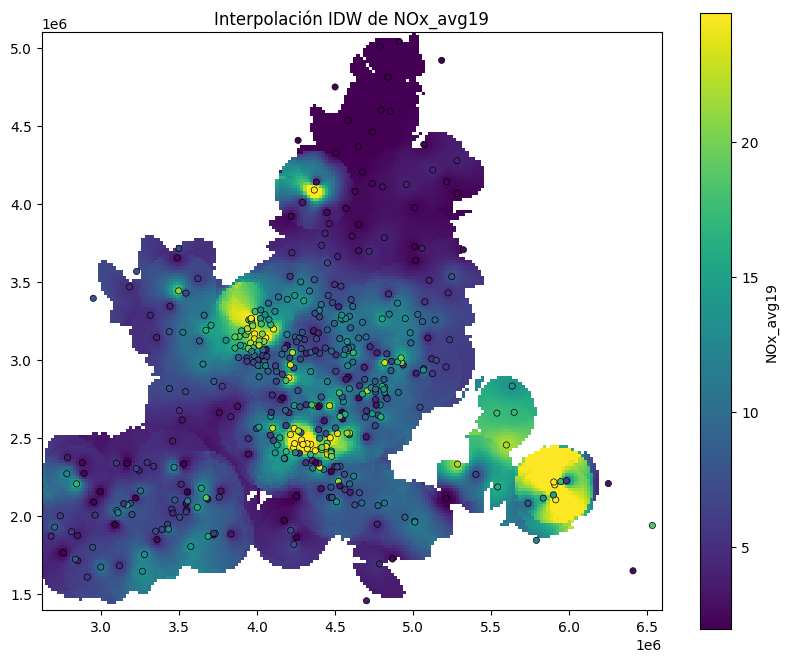

In [40]:
vmin, vmax = np.percentile(values, [5, 95])

fig, ax = plt.subplots(figsize=(10, 8))
mesh = ax.pcolormesh(
    east, 
    north, 
    idw_surface, 
    shading='auto', 
    cmap='viridis', 
    vmin=vmin, 
    vmax=vmax 
    )
ax.scatter(
    x,
    y,
    c=values,
    cmap='viridis',
    edgecolor='black',
    s=20,
    linewidths=0.5,
    vmax=vmax,
    vmin=vmin
)
fig.colorbar(mesh, ax=ax, label='NOx_avg19')
ax.set_title('Interpolación IDW de NOx_avg19')
ax.set_aspect('equal')

plt.show()

In [41]:
# Calcular TIN
from scipy.interpolate import LinearNDInterpolator
tin_interpolator = LinearNDInterpolator(coords, values)
levels = np.linspace(vmin, vmax, 10)

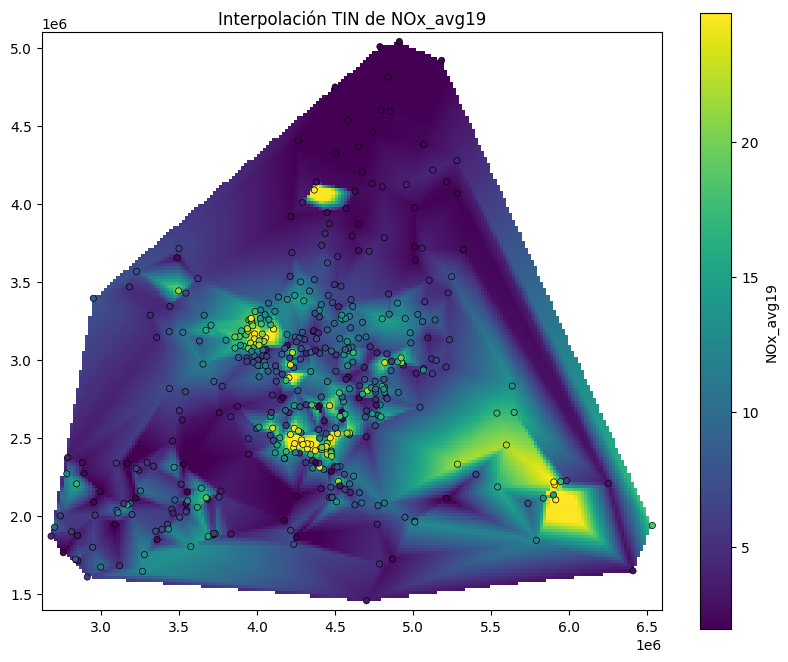

In [42]:
fig, ax = plt.subplots(figsize=(10, 8))
mesh = ax.pcolormesh(
    east, 
    north, 
    tin_interpolator(east.ravel(), north.ravel()).reshape(east.shape), 
    shading='auto', 
    cmap='viridis', 
    vmin=vmin, 
    vmax=vmax
    )

ax.scatter(
    x,
    y,
    c=values,
    cmap='viridis',
    edgecolor='black',
    s=20,
    linewidths=0.5,
    vmax=vmax,
    vmin=vmin
)
fig.colorbar(mesh, ax=ax, label='NOx_avg19')
ax.set_title('Interpolación TIN de NOx_avg19')
ax.set_aspect('equal')
plt.show()